✅ Veri Hazırlandı. Eğitim Örneği: 820 | Test Örneği: 205

                 📊 GELENEKSEL MAKİNE ÖĞRENMESİ MODELLERİ KARŞILAŞTIRMA TABLOSU
                       Yöntem / Model Accuracy Recall 🚨 F1-Score AUC-ROC Süre (sn)
          Lojistik Regresyon (Linear)   0.8098   0.9143   0.8312  0.9298    0.0859
Polinom Lojistik Regresyon (Degree=2)   0.9073   0.9143   0.9100  0.9861    0.1146
  Support Vector Machine (RBF Kernel)   0.9268   0.9429   0.9296  0.9771    0.1374


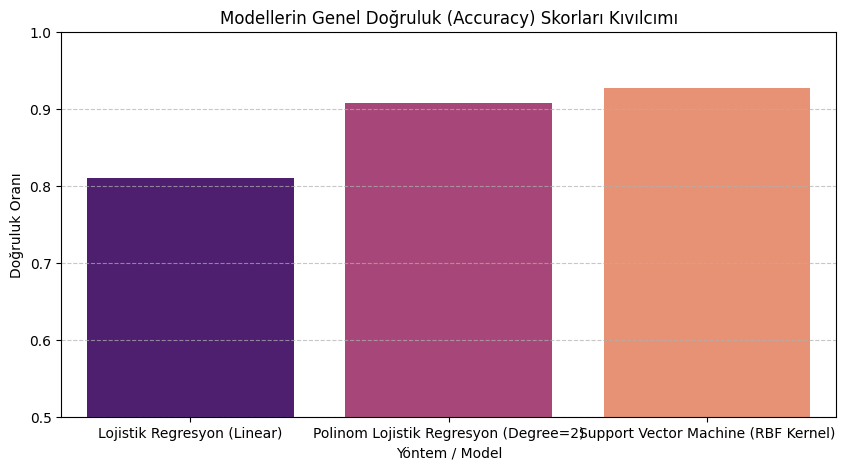

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

# ==============================================================================
# 🛠️ 1. VERİ SETİNİ YÜKLEME VE ÖN İŞLEME (PREPROCESSING)
# ==============================================================================
try:
    # Bilgisayarındaki kalp hastalığı verisini okur.
    df = pd.read_csv('heart.csv')
    X = df.drop('target', axis=1)
    y = df['target']
except FileNotFoundError:
    print("⚠️ 'heart.csv' bulunamadı! Sentetik tıbbi sınıflandırma verisi üretiliyor...")
    from sklearn.datasets import make_classification
    X_raw, y_raw = make_classification(n_samples=1000, n_features=13, n_informative=10, random_state=42)
    X = pd.DataFrame(X_raw, columns=[f'feature_{i}' for i in range(13)])
    y = y_raw

# Veriyi %80 Eğitim, %20 Test olarak bölelim
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 💡 SVM ve Lojistik Regresyon varyans farklarından çok etkilenir, bu yüzden ÖLÇEKLENDİRME (Scaling) şarttır!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Veri Hazırlandı. Eğitim Örneği: {X_train.shape[0]} | Test Örneği: {X_test.shape[0]}\n")

results = []

# ==============================================================================
# 📐 YÖNTEM 1: Standart Lojistik Regresyon (Doğrusal Karar Sınırı)
# ==============================================================================
start = time.time()
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

results.append({
    'Yöntem / Model': 'Lojistik Regresyon (Linear)',
    'Accuracy': accuracy_score(y_test, lr_preds),
    'Recall 🚨': recall_score(y_test, lr_preds),
    'F1-Score': f1_score(y_test, lr_preds),
    'AUC-ROC': roc_auc_score(y_test, lr_probs),
    'Süre (sn)': time.time() - start
})

# ==============================================================================
# 📈 YÖNTEM 2: Polinom Lojistik Regresyon (Doğrusal Olmayan Özellik Genişletme)
# ==============================================================================
start = time.time()
# Özelliklerin 2. dereceden kombinasyonlarını (karesini ve birbiriyle çarpımını) alarak veriyi genişletiyoruz
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_lr_model = LogisticRegression(random_state=42, max_iter=1000)
poly_lr_model.fit(X_train_poly, y_train)
poly_preds = poly_lr_model.predict(X_test_poly)
poly_probs = poly_lr_model.predict_proba(X_test_poly)[:, 1]

results.append({
    'Yöntem / Model': 'Polinom Lojistik Regresyon (Degree=2)',
    'Accuracy': accuracy_score(y_test, poly_preds),
    'Recall 🚨': recall_score(y_test, poly_preds),
    'F1-Score': f1_score(y_test, poly_preds),
    'AUC-ROC': roc_auc_score(y_test, poly_probs),
    'Süre (sn)': time.time() - start
})

# ==============================================================================
# 🔮 YÖNTEM 3: Support Vector Machine — SVM (Kernel Trick ile Yüksek Boyut)
# ==============================================================================
start = time.time()
# RBF (Radial Basis Function) kullanarak veriyi sonsuz boyuta taşır ve orada en iyi hiper-düzlemi çizer
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_preds = svm_model.predict(X_test_scaled)
svm_probs = svm_model.predict_proba(X_test_scaled)[:, 1]

results.append({
    'Yöntem / Model': 'Support Vector Machine (RBF Kernel)',
    'Accuracy': accuracy_score(y_test, svm_preds),
    'Recall 🚨': recall_score(y_test, svm_preds),
    'F1-Score': f1_score(y_test, svm_preds),
    'AUC-ROC': roc_auc_score(y_test, svm_probs),
    'Süre (sn)': time.time() - start
})

# ==============================================================================
# 📊 4. NİHAİ BENCHMARK SKORBORDU
# ==============================================================================
df_results = pd.DataFrame(results)

print('='*110)
print('                 📊 GELENEKSEL MAKİNE ÖĞRENMESİ MODELLERİ KARŞILAŞTIRMA TABLOSU')
print('='*110)
print(df_results.to_string(index=False, formatters={
    'Accuracy': '{:.4f}'.format, 'Recall 🚨': '{:.4f}'.format,
    'F1-Score': '{:.4f}'.format, 'AUC-ROC': '{:.4f}'.format, 'Süre (sn)': '{:.4f}'.format
}))
print('='*110)

# Grafiksel Görselleştirme
plt.figure(figsize=(10, 5))
sns.barplot(x='Yöntem / Model', y='Accuracy', data=df_results, palette='magma')
plt.title('Modellerin Genel Doğruluk (Accuracy) Skorları Kıvılcımı')
plt.ylim(0.5, 1.0)
plt.ylabel('Doğruluk Oranı')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 5. DETAYLI MODEL DEĞERLENDİRMESİ (Classification Report & Confusion Matrix)


=== Lojistik Regresyon (Linear) - DETAYLI RAPOR ===

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205


Confusion Matrix:


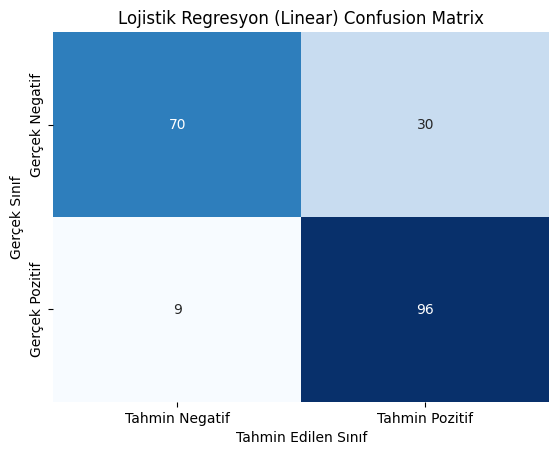


=== Polinom Lojistik Regresyon (Degree=2) - DETAYLI RAPOR ===

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       100
           1       0.91      0.91      0.91       105

    accuracy                           0.91       205
   macro avg       0.91      0.91      0.91       205
weighted avg       0.91      0.91      0.91       205


Confusion Matrix:


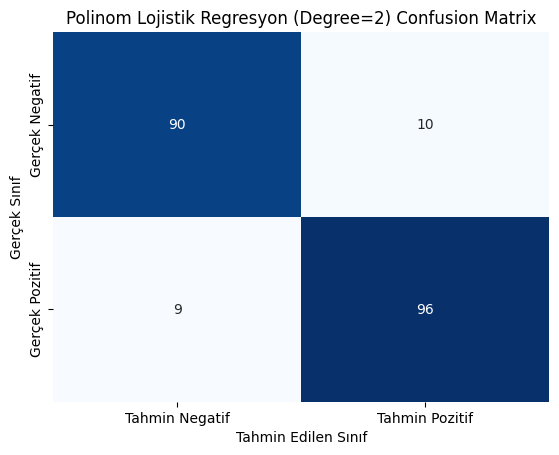


=== Support Vector Machine (RBF Kernel) - DETAYLI RAPOR ===

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       100
           1       0.92      0.94      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205


Confusion Matrix:


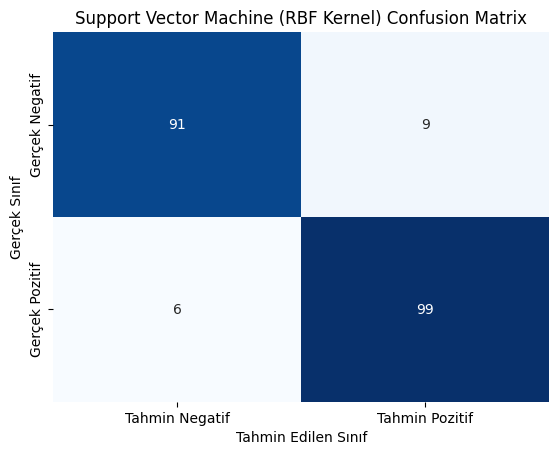

In [2]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model_details(model_name, y_true, y_pred):
    print(f"\n=== {model_name} - DETAYLI RAPOR ===")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Tahmin Negatif', 'Tahmin Pozitif'],
                yticklabels=['Gerçek Negatif', 'Gerçek Pozitif'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Tahmin Edilen Sınıf')
    plt.ylabel('Gerçek Sınıf')
    plt.show()

# Lojistik Regresyon Detaylı Rapor
evaluate_model_details('Lojistik Regresyon (Linear)', y_test, lr_preds)

# Polinom Lojistik Regresyon Detaylı Rapor
evaluate_model_details('Polinom Lojistik Regresyon (Degree=2)', y_test, poly_preds)

# SVM Detaylı Rapor
evaluate_model_details('Support Vector Machine (RBF Kernel)', y_test, svm_preds)

### Modellerin Karmaşıklık Matrisleri Karşılaştırması

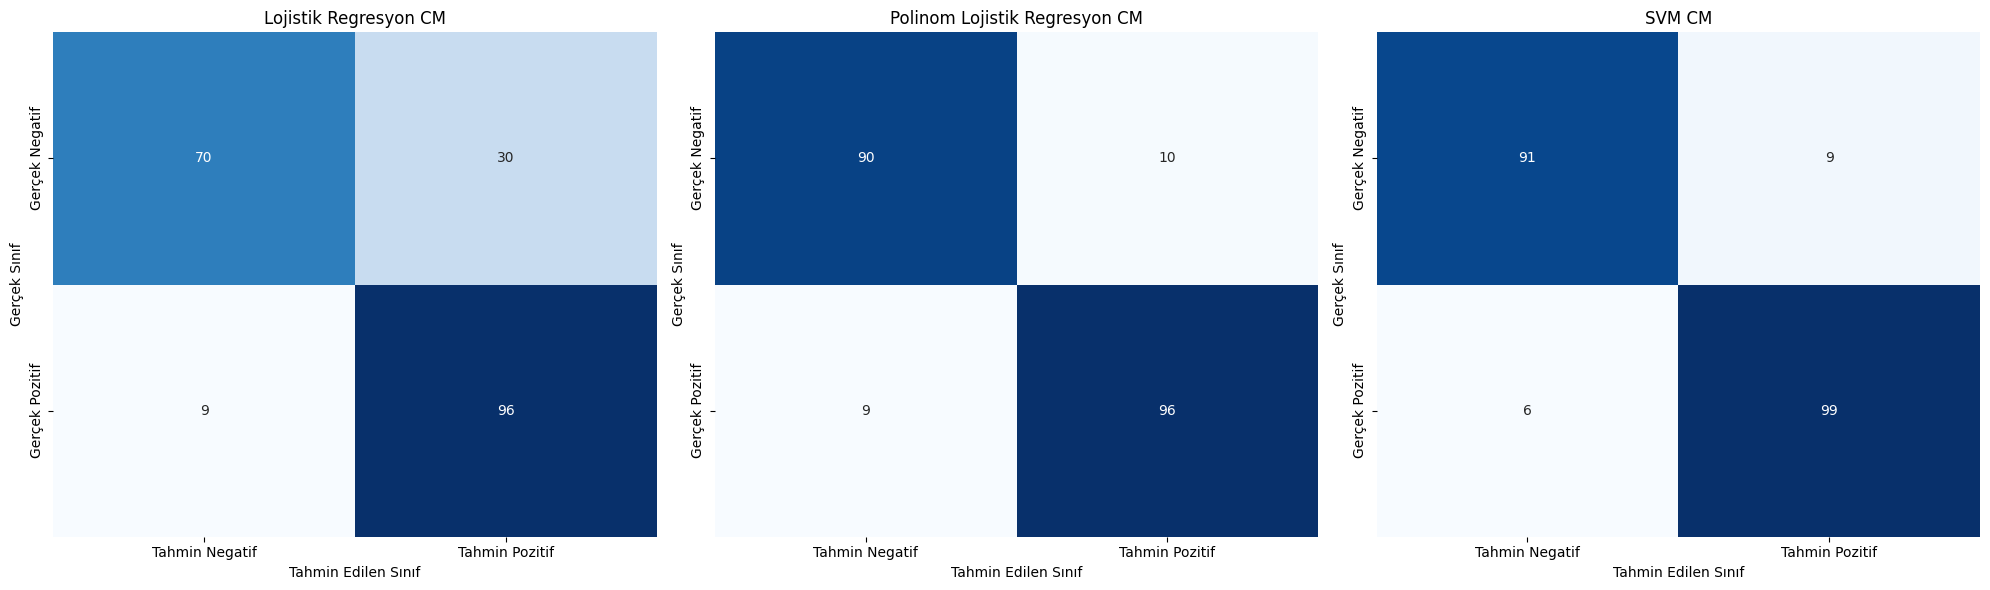

In [9]:
def plot_confusion_matrix_side_by_side(ax, model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Tahmin Negatif', 'Tahmin Pozitif'],
                yticklabels=['Gerçek Negatif', 'Gerçek Pozitif'], ax=ax)
    ax.set_title(f'{model_name} CM')
    ax.set_xlabel('Tahmin Edilen Sınıf')
    ax.set_ylabel('Gerçek Sınıf')

fig, axes = plt.subplots(1, 3, figsize=(20, 6)) # 1 sıra, 3 sütun, 3 confusion matrix için

plot_confusion_matrix_side_by_side(axes[0], 'Lojistik Regresyon', y_test, lr_preds)
plot_confusion_matrix_side_by_side(axes[1], 'Polinom Lojistik Regresyon', y_test, poly_preds)
plot_confusion_matrix_side_by_side(axes[2], 'SVM', y_test, svm_preds)

plt.tight_layout() # Düzenlemeyi iyileştir
plt.show()

## 6. ROC Eğrisi Karşılaştırması

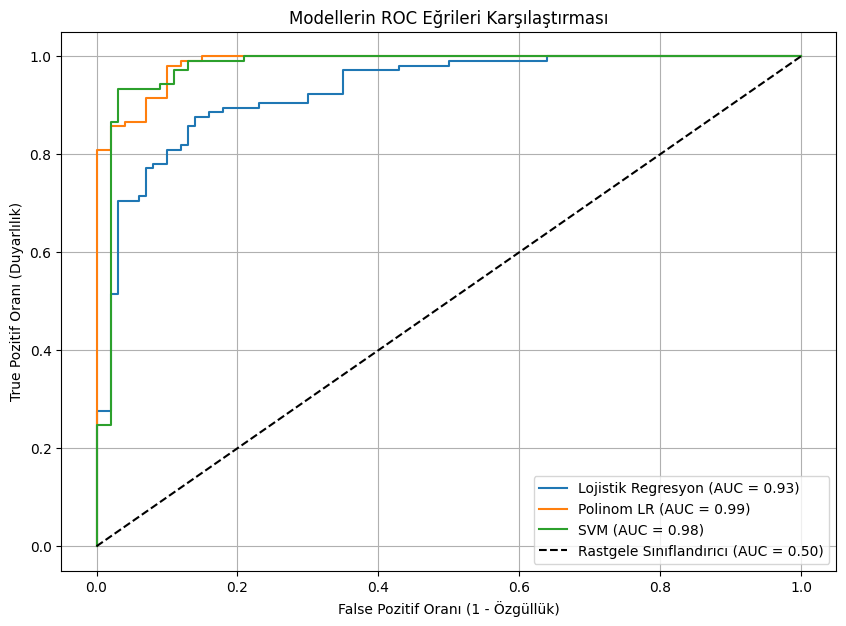

In [3]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))

# Plot ROC curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
plt.plot(fpr_lr, tpr_lr, label=f'Lojistik Regresyon (AUC = {roc_auc_score(y_test, lr_probs):.2f})')

# Plot ROC curve for Polynomial Logistic Regression
fpr_poly_lr, tpr_poly_lr, _ = roc_curve(y_test, poly_probs)
plt.plot(fpr_poly_lr, tpr_poly_lr, label=f'Polinom LR (AUC = {roc_auc_score(y_test, poly_probs):.2f})')

# Plot ROC curve for SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_score(y_test, svm_probs):.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Rastgele Sınıflandırıcı (AUC = 0.50)') # Diagonal random classifier line
plt.xlabel('False Pozitif Oranı (1 - Özgüllük)')
plt.ylabel('True Pozitif Oranı (Duyarlılık)')
plt.title('Modellerin ROC Eğrileri Karşılaştırması')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 8. Hata Analizi: Yanlış Pozitifler ve Yanlış Negatifler (SVM Modeli)

In [4]:
# Y_test'i ve model tahminlerini bir DataFrame'e dönüştürerek kolayca karşılaştırabiliriz.
# 'X_test' zaten oluşturulmuştu. Şimdi gerçek etiketleri ve tahminleri ekleyelim.
error_analysis_df = X_test.copy()
error_analysis_df['Gerçek Etiket'] = y_test.values
error_analysis_df['Tahmin Edilen Etiket'] = svm_preds

# Yanlış Pozitifler (Gerçek: 0, Tahmin: 1)
false_positives = error_analysis_df[(error_analysis_df['Gerçek Etiket'] == 0) & (error_analysis_df['Tahmin Edilen Etiket'] == 1)]

# Yanlış Negatifler (Gerçek: 1, Tahmin: 0)
false_negatives = error_analysis_df[(error_analysis_df['Gerçek Etiket'] == 1) & (error_analysis_df['Tahmin Edilen Etiket'] == 0)]

print(f"\nToplam Yanlış Pozitif Sayısı: {len(false_positives)}")
if not false_positives.empty:
    print("Yanlış Pozitif Örneklerinden İlk 5'i:\n")
    display(false_positives.head())
else:
    print("Hiç Yanlış Pozitif bulunamadı.")

print(f"\nToplam Yanlış Negatif Sayısı: {len(false_negatives)}")
if not false_negatives.empty:
    print("Yanlış Negatif Örneklerinden İlk 5'i:\n")
    display(false_negatives.head())
else:
    print("Hiç Yanlış Negatif bulunamadı.")


Toplam Yanlış Pozitif Sayısı: 9
Yanlış Pozitif Örneklerinden İlk 5'i:



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Gerçek Etiket,Tahmin Edilen Etiket
554,58,1,0,100,234,0,1,156,0,0.1,2,1,3,0,1
646,47,1,2,108,243,0,1,152,0,0.0,2,0,2,0,1
407,58,1,0,100,234,0,1,156,0,0.1,2,1,3,0,1
429,47,1,2,108,243,0,1,152,0,0.0,2,0,2,0,1
684,60,1,2,140,185,0,0,155,0,3.0,1,0,2,0,1



Toplam Yanlış Negatif Sayısı: 6
Yanlış Negatif Örneklerinden İlk 5'i:



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Gerçek Etiket,Tahmin Edilen Etiket
353,57,1,0,110,201,0,1,126,1,1.5,1,0,1,1,0
887,57,1,0,110,201,0,1,126,1,1.5,1,0,1,1,0
880,57,1,0,132,207,0,1,168,1,0.0,2,0,3,1,0
913,45,1,0,104,208,0,0,148,1,3.0,1,0,2,1,0
276,57,1,0,132,207,0,1,168,1,0.0,2,0,3,1,0


### Yanlış Pozitif ve Yanlış Negatif Örneklerin Özellik Dağılımları Karşılaştırması

Şimdi de Yanlış Pozitif ve Yanlış Negatif olarak sınıflandırılan örneklerin belirli özelliklerinin dağılımlarını karşılaştırarak, modelin bu iki hata türünde neden zorlandığını anlamaya çalışalım.

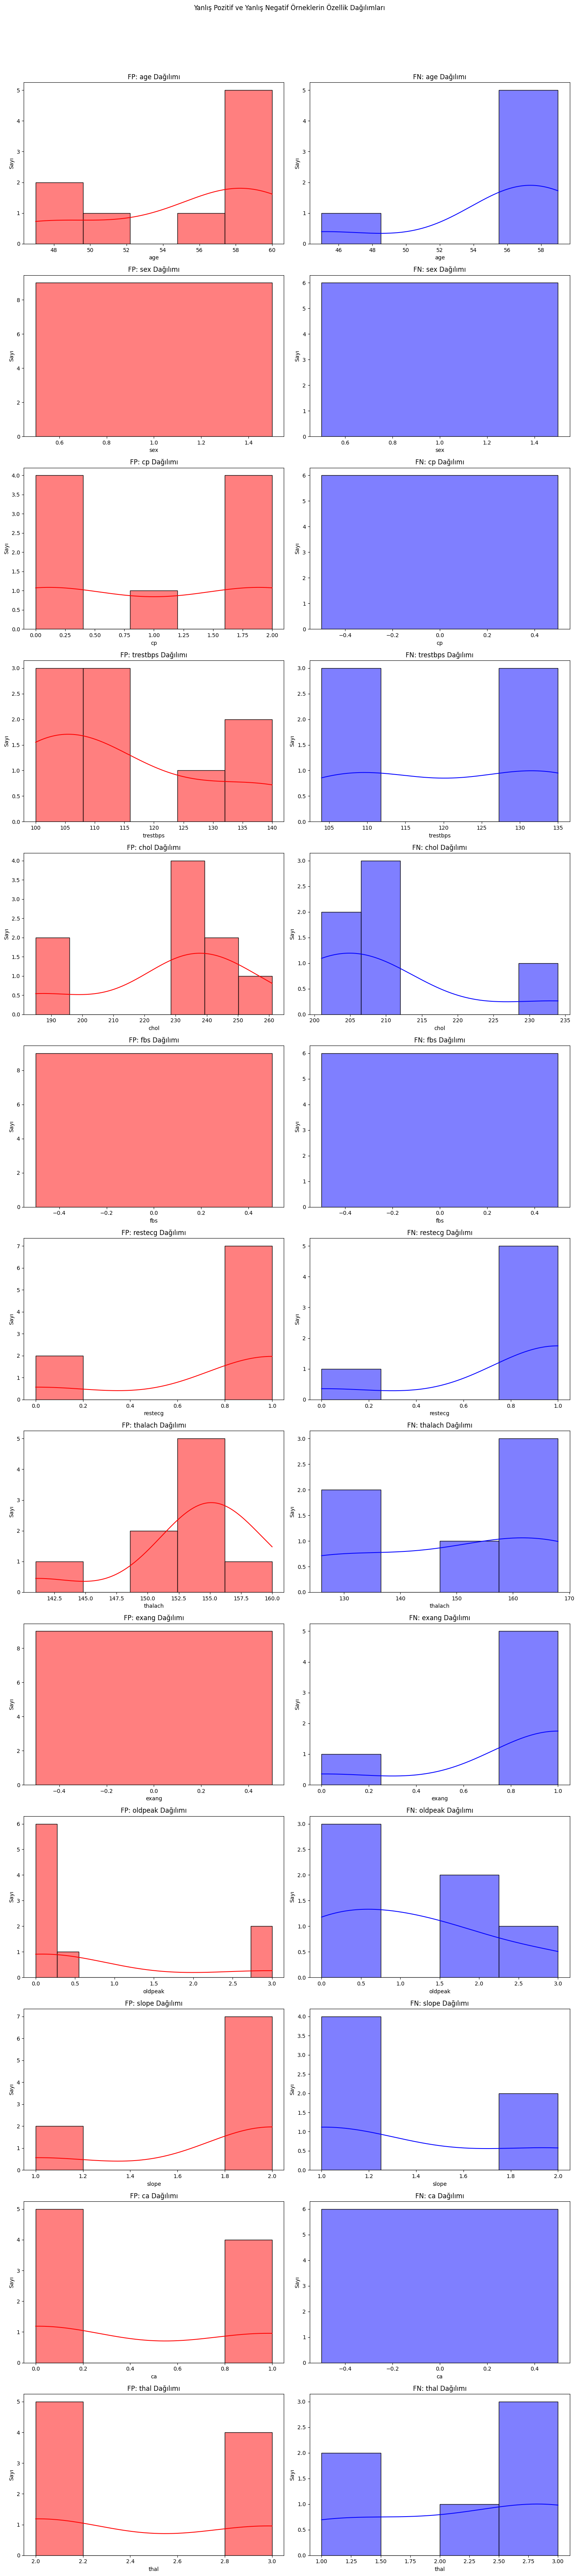

In [5]:
if not false_positives.empty or not false_negatives.empty:
    fig, axes = plt.subplots(len(X.columns), 2, figsize=(15, 5 * len(X.columns)))
    fig.suptitle('Yanlış Pozitif ve Yanlış Negatif Örneklerin Özellik Dağılımları', y=1.02)

    for i, feature in enumerate(X.columns):
        # Yanlış Pozitifler için dağılım
        if not false_positives.empty:
            sns.histplot(false_positives[feature], kde=True, color='red', ax=axes[i, 0])
        axes[i, 0].set_title(f'FP: {feature} Dağılımı')
        axes[i, 0].set_ylabel('Sayı')

        # Yanlış Negatifler için dağılım
        if not false_negatives.empty:
            sns.histplot(false_negatives[feature], kde=True, color='blue', ax=axes[i, 1])
        axes[i, 1].set_title(f'FN: {feature} Dağılımı')
        axes[i, 1].set_ylabel('Sayı')

    plt.tight_layout()
    plt.show()
else:
    print("Hata analizi için Yanlış Pozitif veya Yanlış Negatif örnek bulunamadı.")

### Yanlış Pozitif ve Yanlış Negatif Örneklerin Özellik Ortalamaları Karşılaştırması

In [6]:
print("\n=== Yanlış Pozitif (FP) Özellik Ortalamaları ===")
if not false_positives.empty:
    display(false_positives[X.columns].mean().to_frame(name='Ortalama'))
else:
    print("Yanlış Pozitif örnek bulunamadı.")

print("\n=== Yanlış Negatif (FN) Özellik Ortalamaları ===")
if not false_negatives.empty:
    display(false_negatives[X.columns].mean().to_frame(name='Ortalama'))
else:
    print("Yanlış Negatif örnek bulunamadı.")

# Opsiyonel: Tüm test setinin ortalaması ile karşılaştırma için
print("\n=== Tüm Test Seti Özellik Ortalamaları ===")
display(X_test.mean().to_frame(name='Ortalama'))


=== Yanlış Pozitif (FP) Özellik Ortalamaları ===


,Ortalama
age,55.222222
sex,1.000000
cp,1.000000
trestbps,114.666667
chol,227.666667
fbs,0.000000
restecg,0.777778
thalach,153.666667
exang,0.000000
oldpeak,0.733333



=== Yanlış Negatif (FN) Özellik Ortalamaları ===


,Ortalama
age,55.333333
sex,1.000000
cp,0.000000
trestbps,120.500000
chol,209.666667
fbs,0.000000
restecg,0.833333
thalach,149.500000
exang,0.833333
oldpeak,1.083333



=== Tüm Test Seti Özellik Ortalamaları ===


,Ortalama
age,53.712195
sex,0.697561
cp,0.995122
trestbps,128.663415
chol,238.263415
fbs,0.131707
restecg,0.590244
thalach,148.058537
exang,0.321951
oldpeak,1.045854


### Yanlış Pozitif, Yanlış Negatif ve Tüm Test Seti Özellik Ortalamaları Karşılaştırmalı Tablosu

In [7]:
comparison_table = pd.DataFrame({
    'FP Ortalaması': false_positives[X.columns].mean(),
    'FN Ortalaması': false_negatives[X.columns].mean(),
    'Tüm Test Seti Ortalaması': X_test.mean()
})

print("\n=== Özellik Ortalamaları Karşılaştırmalı Tablosu ===")
display(comparison_table)


=== Özellik Ortalamaları Karşılaştırmalı Tablosu ===


,FP Ortalaması,FN Ortalaması,Tüm Test Seti Ortalaması
age,55.222222,55.333333,53.712195
sex,1.000000,1.000000,0.697561
cp,1.000000,0.000000,0.995122
trestbps,114.666667,120.500000,128.663415
chol,227.666667,209.666667,238.263415
fbs,0.000000,0.000000,0.131707
restecg,0.777778,0.833333,0.590244
thalach,153.666667,149.500000,148.058537
exang,0.000000,0.833333,0.321951
oldpeak,0.733333,1.083333,1.045854


### Model Metrikleri Karşılaştırması (Recall, F1-Score, AUC-ROC)

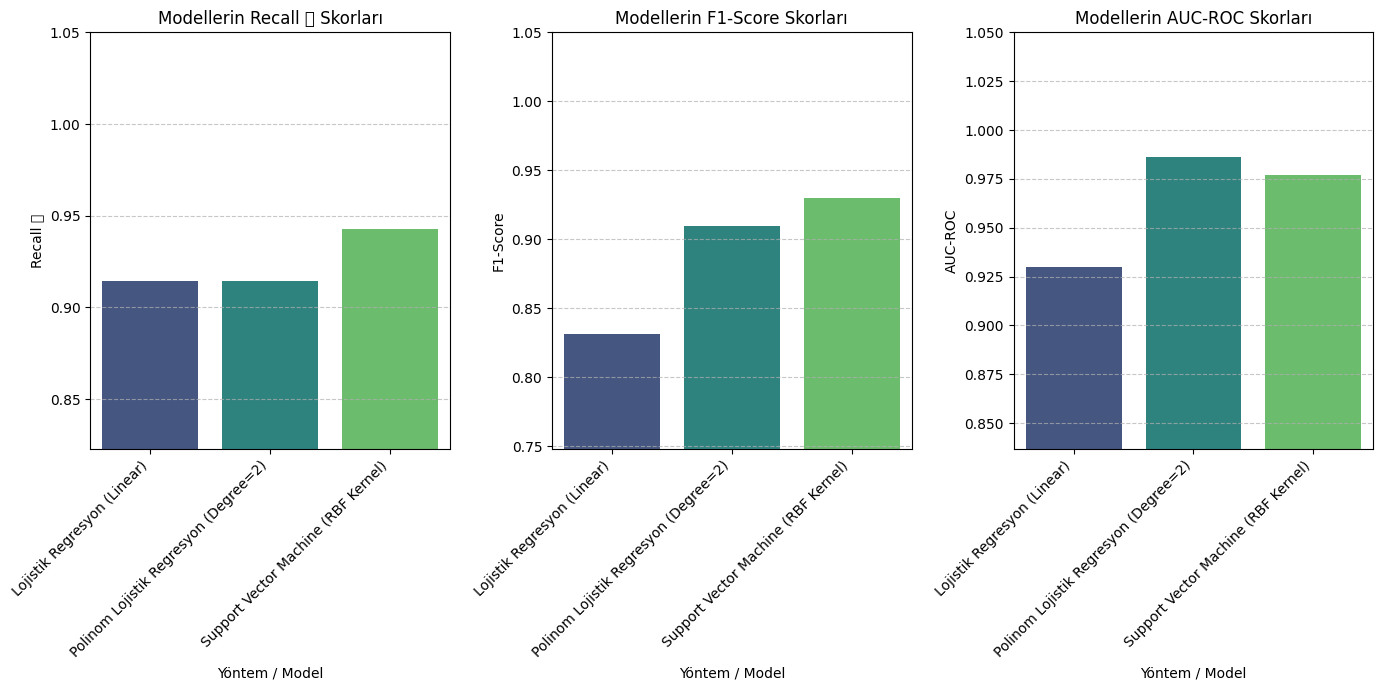

In [8]:
metrics_to_plot = ['Recall 🚨', 'F1-Score', 'AUC-ROC']

plt.figure(figsize=(14, 7))

# Iterate over each metric and create a subplot
for i, metric in enumerate(metrics_to_plot):
    plt.subplot(1, len(metrics_to_plot), i + 1) # Create subplot (1 row, N columns)
    sns.barplot(x='Yöntem / Model', y=metric, data=df_results, palette='viridis')
    plt.title(f'Modellerin {metric} Skorları')
    plt.ylim(df_results[metric].min() * 0.9, 1.05) # Adjust y-axis for better visibility
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()